### Exploratory Data Analysis
Проведемо експлораторний аналіз даних для задачі класифікації твітів.
Наші цілі: 
1) завантажити дані;
2) перевірити наявність пропусків (NaN);
3) сформулювати робочі гіпотези; 
4) перевірити баланс класів;
5) проаналізувати Distributions фізичних характеристик тексту (довжина твітів);
6) додати синтетичні дані для балансування (Oversampling);
7) зробити висновки.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

df = pd.read_csv("train.csv")

print("Загальна інформація про датасет")
print(df.info())
print("Приклади твітів:")
print("-" * 50)

count = 0
for text in df['text']:
    if 'http' in text or '@' in text:
        print(f"Твіт: {text}")
        print("-" * 50)
        count += 1
    
    if count == 3:
        break

print("\nПеревірка на наявність пропущених значень (NaN)")
print(df.isna().sum())

Загальна інформація про датасет
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None
Приклади твітів:
--------------------------------------------------
Твіт: @bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C
--------------------------------------------------
Твіт: We always try to bring the heavy. #metal #RT http://t.co/YAo1e0xngw
--------------------------------------------------
Твіт: #AFRICANBAZE: Breaking news:Nigeria flag set ablaze in Aba. http://t.co/2nndBGwyEi
--------------------------------------------------

Перевірка на наявність пропущених значень (NaN)
id             0
keyword       61
location  

Твіти переповнені URL-посиланнями, згадками користувачів, хештегами, розділовими знаками та мають різний регістр букв, що призводить до різного трактування одного слова.
Датасет складається з текстових полів `text`, міток класів `target`, а також додаткових метаданих `keyword`, `location`. Ключові колонки `text` та `target` не містять жодного пропущеного значення, що дозволяє нам використовувати тексти без ризику втрати рядків. Пропуски є лише в метаданих (`location` та `keyword`), тому в поточному дослідженні ми сфокусуємося виключно на аналізі самого тексту повідомлень.
Перш ніж будувати алгоритм, необхідно перевірити баланс класів цільової мітки `target`, де 1 — це твіт про реальну катастрофу, а 0 — звичайне повідомлення.

**Гіпотеза** H0: У сирих даних присутній дисбаланс у бік класу 0. Якщо його не усунути, модель буде упередженою і матиме низьку метрику Recall (повноту) для цільового класу 1.

**Гіпотеза H1**: Повідомлення про реальні катастрофи мають інший характер розподілу довжини (вони є більш довгими або лаконічними), і цей розподіл підпорядковується закону нормального розподілу.

Твітів про катастрофи (Клас 1): 3271
Звичайних твітів (Клас 0): 4342


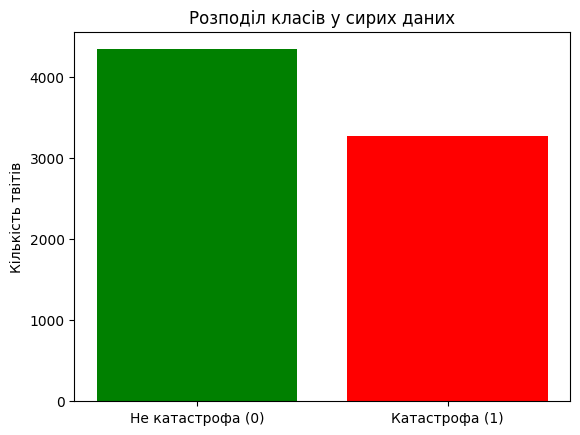

In [15]:

disaster_count = 0     
normal_count = 0
   
for target in df['target']:     #підраховуємо класи
    if target == 1:
        disaster_count += 1
    else:
        normal_count += 1

print(f"Твітів про катастрофи (Клас 1): {disaster_count}")     #виводимо результати
print(f"Звичайних твітів (Клас 0): {normal_count}")

classes = ['Не катастрофа (0)', 'Катастрофа (1)']      #малюємо графік
counts = [normal_count, disaster_count]

plt.bar(classes, counts, color=['green', 'red'])
plt.title('Розподіл класів у сирих даних')
plt.ylabel('Кількість твітів')
plt.show()

Гіпотезу H0 було підтверджено: звичайних повідомлень справді більше.
Для перевірки Гіпотези H1 дослідимо фізичну характеристику текстів — їхню довжину в символах. Нам потрібно побудувати гістограму розподілу для кожного класу окремо, щоб побачити їхню форму та перевірити, чи є розподіл нормальним.

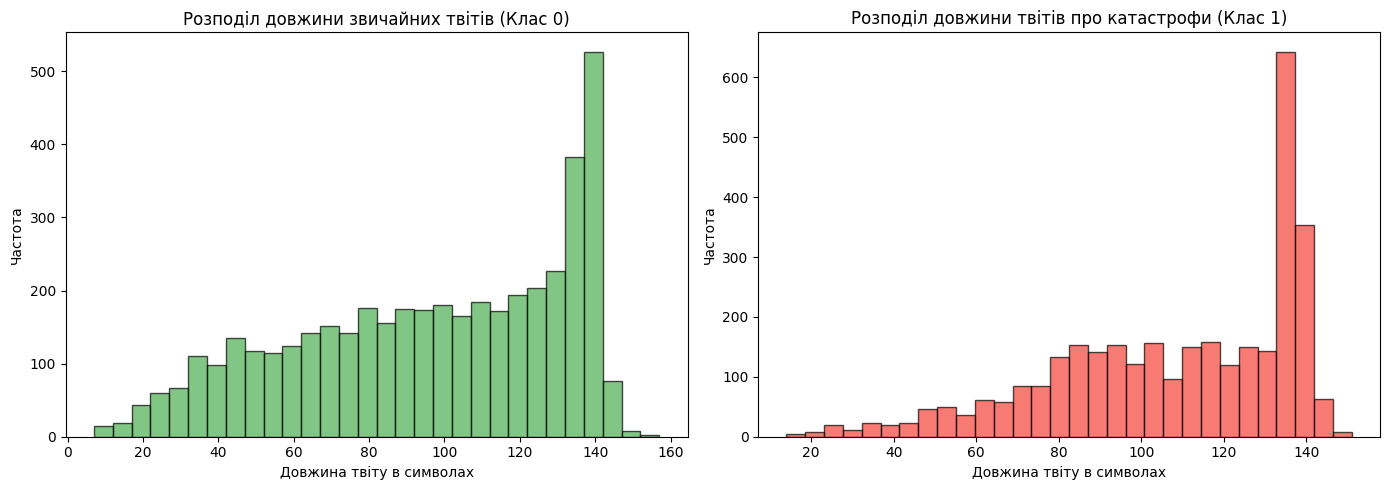

In [16]:
lengths_normal = []
lengths_disaster = []

for index, row in df.iterrows():
    text_len = len(str(row['text']))
    if row['target'] == 0:
        lengths_normal.append(text_len)
    else:
        lengths_disaster.append(text_len)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(lengths_normal, bins=30, color='#4CAF50', alpha=0.7, edgecolor='black')
ax[0].set_title('Розподіл довжини звичайних твітів (Клас 0)')
ax[0].set_xlabel('Довжина твіту в символах')
ax[0].set_ylabel('Частота')

ax[1].hist(lengths_disaster, bins=30, color='#F44336', alpha=0.7, edgecolor='black')
ax[1].set_title('Розподіл довжини твітів про катастрофи (Клас 1)')
ax[1].set_xlabel('Довжина твіту в символах')
ax[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Візуалізація показує, що розподіл довжини не є нормальним через ліміти платформи і має виражену асиметрію, але ми чітко бачимо різну поведінку текстів.  Графіки мають різко обірваний правий край. Це пояснюється не властивостями самого тексту, а технічним лімітом платформи Twitter. Дані є штучно зрізаними, тому класичний нормальний розподіл тут неможливий. Повідомлення про катастрофи є довшими та щільніше згруповані біля максимальної межі символів. Звичайні твіти мають більш плавний розподіл і частіше бувають короткими.  Гіпотезу про нормальний розподіл відхилено через специфіку Twitter, але доведено, що довжина тексту є важливою ознакою, яка відрізняє справжні катастрофи від звичайних дописів.
Оскільки звичайних твітів більше, ніж твітів про катастрофи, для балансування даних застосуємо метод **Oversampling**. Щоб зрівняти кількість твітів, ми додамо синтетичні дані до класу 1.

In [17]:
disaster_tweets = df[df['target'] == 1]     #розподіляємо дані на два набори
normal_tweets = df[df['target'] == 0]

difference = normal_count - disaster_count       #рахуємо недостачу твітів про катастрофи
print(f"Бракує {difference} твітів про катастрофи для ідеального балансу.")

synthetic_data = disaster_tweets.sample(n=difference, replace=True, random_state=42)   #створюємо шляхом копіювання твітів з класу 1 синтетичні дані

balanced_df = pd.concat([df, synthetic_data])    #доєднуємо синтетичні дані до загальної бази

new_disaster_count = len(balanced_df[balanced_df['target'] == 1])   #знову перевіряємо баланс
new_normal_count = len(balanced_df[balanced_df['target'] == 0])

print(f"\nНовий баланс:")
print(f"Твітів про катастрофи (Клас 1): {new_disaster_count}")
print(f"Звичайних твітів (Клас 0): {new_normal_count}")

Бракує 1071 твітів про катастрофи для ідеального балансу.

Новий баланс:
Твітів про катастрофи (Клас 1): 4342
Звичайних твітів (Клас 0): 4342


### Insights
Щодо якості вхідних даних, то вони містять багато такого "сміття" як посилання, смайлики, розділові знаки, що вимагає очистки даних перед побудовою моделі. Аналіз дистрибуції довжини твітів показав відхилення від класичного нормального розподілу через штучні обмеження платформи Twitter. Проте було виявлено закономірність, що інформаційні повідомлення про катастрофи мають більшу щільність у зоні максимальної довжини. Було встановлено незначний дисбаланс даних: кількість звичайних твітів трохи перевищувала кількість твітів про катастрофу, що вимагало збалансування додаванням синтетичних даних. Це дозволяє моделі краще вивчити ознаки реальних катастроф.

### Model
Проведемо текстову очистку, перетворимо слова на числа за допомогою TF-IDF з лімітом у 3000 найважливіших слів для оптимізації пам'яті та навчимо базову логістину регресію. Для оцінки якості моделі побудуємо матрицю помилок Confusion matrix та детальний Classification report.
Проте перш за все заради експерименту спробуємо навчити модель на незбалансованих сирих даних та проаналізувати отримані результати.

CLASSIFICATION REPORT (дані незбалансовані)
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      4342
           1       0.89      0.76      0.82      3271

    accuracy                           0.86      7613
   macro avg       0.86      0.84      0.85      7613
weighted avg       0.86      0.86      0.86      7613


CONFUSION MATRIX (дані незбалансовані)
[[4041  301]
 [ 788 2483]]


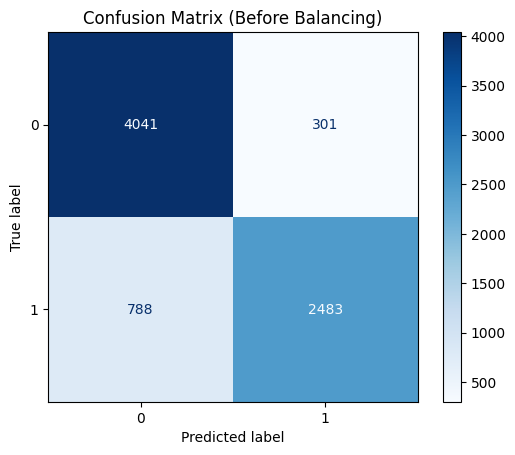

In [29]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

train_data = pd.read_csv("train.csv") 
def clean_tweet_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # видаляємо посилання
    text = re.sub(r'[^a-z0-9\s]', '', text)  # залишаємо тільки букви та цифри
    return text

cleaned_list = []
for t in balanced_df['text']:
    cleaned_list.append(clean_tweet_text(t))

X_raw = vectorizer.transform(train_data['text'].apply(clean_tweet_text))
y_raw = train_data['target']

model_raw = LogisticRegression(max_iter=1000)
model_raw.fit(X_raw, y_raw)
predictions_raw = model_raw.predict(X_raw)

print("CLASSIFICATION REPORT (дані незбалансовані)")
print(classification_report(y_raw, predictions_raw))

print("\nCONFUSION MATRIX (дані незбалансовані)")
print(confusion_matrix(y_raw, predictions_raw))

ConfusionMatrixDisplay.from_estimator(model_raw, X_raw, y_raw, cmap='Blues')
plt.title("Confusion Matrix (Before Balancing)")
plt.show()

На перший погляд модель володіє доволі високою точністю у 86%, проте ця точність оманлива, оскільки модель навчалась на даних, де переважали звичайні твіти. На катастрофічність такої моделі вказує кількість пропущених твітів про реальні катастрофи, а саме 788 твітів. Це вказує на пряму необхідність збалансувати дані перед навчанням.

Розмірність даних Логістичної регресії: (8684, 3000) 

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       858
           1       0.83      0.77      0.80       879

    accuracy                           0.80      1737
   macro avg       0.80      0.80      0.80      1737
weighted avg       0.80      0.80      0.80      1737

CONFUSION MATRIX
[[717 141]
 [201 678]]


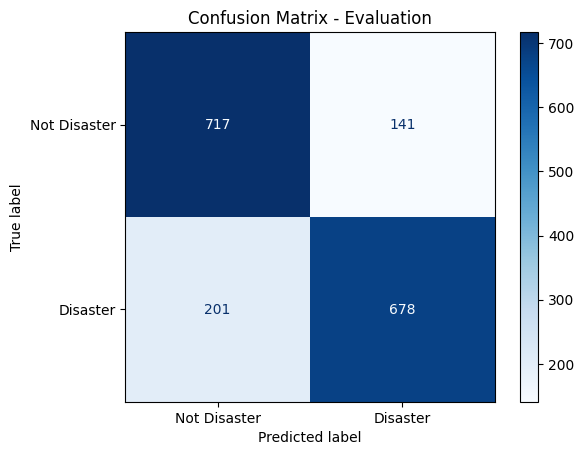

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def clean_tweet_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # видаляємо посилання
    text = re.sub(r'[^a-z0-9\s]', '', text)  # залишаємо тільки букви та цифри
    return text

cleaned_list = []
for t in balanced_df['text']:
    cleaned_list.append(clean_tweet_text(t))

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(cleaned_list)
print(f"Розмірність даних Логістичної регресії: {X.shape} ")
y = balanced_df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

research_model = LogisticRegression()
research_model.fit(X_train, y_train)

predictions = research_model.predict(X_test)
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, predictions))

print("CONFUSION MATRIX")
print(confusion_matrix(y_test, predictions))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    predictions, 
    display_labels=["Not Disaster", "Disaster"], 
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Evaluation")
plt.show()

### Insights
Отримана матриця помилок дає нам чітке розуміння сильних та слабких сторін нашої моделі на тестовій вибірці:
* **True Negatives (717):** Модель успішно ідентифікувала 717 звичайних повсякденних твітів.
* **True Positives (678):** Модель правильно виявила 678 повідомлень про справжні катастрофи.
* **False Positives (141 — "Хибна тривога"):** 141 звичайний твіт був помилково класифікований як небезпека. З огляду на специфіку даних, це очікувано: люди часто використовують слова-маркери в переносному значенні.
* **False Negatives (201 — "Пропущена небезпека"):** 201 твіт про реальну біду модель не змогла розпізнати. Це складні випадки, де текст, імовірно, не містив типових тривожних слів зі словника TF-IDF.
Навчена на збалансованих даних модель продемонструвала високі метрики стабільності: рівень Accuracy та метрика F1 для обох класів знаходяться на хорошому рівні (понад 0.8). Модель однаково добре розпізнає як повсякденні розмови, так і критичні повідомлення про надзвичайні ситуації.
Проте детальне дослідження метрик виявило критичну вразливість: метрика **`recall` для класу 1 становить лише 0.77**. Це означає, що модель пропускає 23% реальних повідомлень про небезпеку. Щоб спробувати вирішити цю проблему, застосуємо полегшену версію архітектури BERT. 

In [ ]:
#import sys
#import subprocess
#subprocess.check_call([sys.executable, "-m", "pip", "install", "sentence-transformers"])


Починаємо встановлення...
Встановлення успішно завершено!


In [18]:

from sentence_transformers import SentenceTransformer
import numpy as np

print("Експеримент: Завантаження Мовної Моделі (BERT)")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

X_embeddings = embedding_model.encode(cleaned_list)

print(f"Нова розмірність даних: {X_embeddings.shape}")
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42
)

bert_log_model = LogisticRegression(max_iter=1000)
bert_log_model.fit(X_train_emb, y_train_emb)

bert_predictions = bert_log_model.predict(X_test_emb)
print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test_emb, bert_predictions))

print("\nCLASSIFICATION REPORT (Мовна модель + Логістична Регресія)")
print(classification_report(y_test_emb, bert_predictions))



Експеримент: Завантаження Мовної Моделі (BERT)
Нова розмірність даних: (8684, 384)

CONFUSION MATRIX
[[720 138]
 [190 689]]

CLASSIFICATION REPORT (Мовна модель + Логістична Регресія)
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       858
           1       0.83      0.78      0.81       879

    accuracy                           0.81      1737
   macro avg       0.81      0.81      0.81      1737
weighted avg       0.81      0.81      0.81      1737



Використання мовної моделі дало кращі результати при розпізнаванні прихованих катастроф. До того ж модель змогла зменшити кількість ознак до 384 векторів, а кількість пропущених катастроф упала до 190. Щодо метрик, то видно деяке покращення. Проте `recall` для класу 1 зріс до 0.78, що не надто суттєво змінило попередню ситуацію. 

### Conclusion
Оскільки різниця у метриці `recall` є не критичною, то хоча мовна модель BERT показала кращу здатність знаходити приховані катастрофи, для створення скриптів та реалізації моделі оберемо **Logistic Regression + TF-IDF**.